# Анализ речи: `Ы` и `Ш`

В этой работе разбираем два звука: `Ы.wav` и `Ш.wav`.

---
## Что делаем

Смотрим, как по-разному можно оценить спектр сигнала: FFT, LPC (Burg), LPC (Левинсон–Дарбин), кепстральная огибающая и Welch.

Потом проверяем, как влияет порядок LPC, смотрим корни `A(z)`, спектрограммы и residual.

In [15]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
from scipy import signal
import matplotlib

import matplotlib.pyplot as plt

from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.grid'] = False


try:
    import soundfile as sf
    SOUND_BACKEND = 'soundfile'
except Exception:
    sf = None
    from scipy.io import wavfile
    SOUND_BACKEND = 'scipy.io.wavfile'

try:
    import librosa
    LIBROSA_AVAILABLE = True
except Exception:
    LIBROSA_AVAILABLE = False

from IPython.display import display, Markdown

os.environ.setdefault('MPLCONFIGDIR', str(Path('.mplconfig').resolve()))

SEED = 42
np.random.seed(SEED)

FS = 16000
DURATION = 1.0
TARGET_SAMPLES = int(FS * DURATION)

PRE_EMPH = 0.97
NFFT = 2048
LIFTER_BINS = 35
WELCH_NPERSEG = 1024
WELCH_NOVERLAP = 512

P_OPT = 2 + FS // 1000
LPC_ORDERS = [4, 8, 12, 18, 26, 40]
EPS = 1e-12

BASE_DIR = Path.cwd()

INPUT_VOWEL = BASE_DIR / 'Ы.wav'
INPUT_SH = BASE_DIR / 'Ш.wav'

if not INPUT_VOWEL.exists() or not INPUT_SH.exists():
    raise FileNotFoundError('Ожидались файлы Ы.wav и Ш.wav в текущей директории ноутбука.')

print(f'Рабочая директория: {BASE_DIR}')
print(f'Аудио backend: {SOUND_BACKEND}')
print(f'librosa доступна: {LIBROSA_AVAILABLE}')
print(f'P_OPT = {P_OPT} (правило 2 + Fs/1000)')


Рабочая директория: /home/nikita/Code/MSU/cmc_msu_ml/Rech_Max/Problem2
Аудио backend: soundfile
librosa доступна: False
P_OPT = 18 (правило 2 + Fs/1000)


---
## Подготовка сигналов

Сначала приводим оба файла к одному виду:
- один канал (моно),
- частота `16 кГц`,
- кусок длиной `1 секунда`,
- сглаживаем начало и конец,
- нормализация уровня.

### Как это понимать

`Ы` больше похож на голосовой звук: есть регулярная структура.

`Ш` больше похож на шум: энергии больше в высоких частотах.

In [16]:
def read_audio_mono(path: Path) -> tuple[np.ndarray, int]:
    path = Path(path)
    if sf is not None:
        x, fs = sf.read(path)
    else:
        fs, x = wavfile.read(path)
        if np.issubdtype(x.dtype, np.integer):
            x = x.astype(np.float64) / np.iinfo(x.dtype).max
        else:
            x = x.astype(np.float64)

    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 2:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    return x, int(fs)


def resample_to_fs(x: np.ndarray, fs_in: int, fs_out: int = FS) -> np.ndarray:
    if fs_in == fs_out:
        return x.copy()
    g = np.gcd(fs_in, fs_out)
    up = fs_out // g
    down = fs_in // g
    return signal.resample_poly(x, up, down)


def extract_active_segment(
    x: np.ndarray,
    fs: int,
    target_duration: float = DURATION,
    frame_ms: float = 20.0,
    threshold_ratio: float = 0.18,
) -> np.ndarray:
    target_len = int(round(target_duration * fs))
    if len(x) == 0:
        return np.zeros(target_len, dtype=np.float64)

    frame_len = max(1, int(round(frame_ms * 1e-3 * fs)))
    n_frames = max(1, len(x) // frame_len)

    rms = []
    for i in range(n_frames):
        seg = x[i * frame_len:(i + 1) * frame_len]
        if len(seg) == 0:
            continue
        rms.append(np.sqrt(np.mean(seg ** 2) + EPS))
    rms = np.asarray(rms)

    if len(rms) == 0:
        center = len(x) // 2
    else:
        thr = threshold_ratio * np.max(rms)
        active = np.where(rms >= thr)[0]
        if len(active) == 0:
            center = len(x) // 2
        else:
            start = int(active[0] * frame_len)
            end = int(min(len(x), (active[-1] + 1) * frame_len))
            center = (start + end) // 2

    start = center - target_len // 2
    end = start + target_len

    out = np.zeros(target_len, dtype=np.float64)
    src_start = max(0, start)
    src_end = min(len(x), end)
    dst_start = src_start - start

    if src_end > src_start:
        out[dst_start:dst_start + (src_end - src_start)] = x[src_start:src_end]

    return out


def apply_fade(x: np.ndarray, fs: int, attack_ms: float, release_ms: float) -> np.ndarray:
    y = x.copy()
    n = len(y)
    n_attack = int(round(attack_ms * 1e-3 * fs))
    n_release = int(round(release_ms * 1e-3 * fs))

    if n_attack > 0:
        n_attack = min(n_attack, n)
        y[:n_attack] *= np.linspace(0.0, 1.0, n_attack, endpoint=True)

    if n_release > 0:
        n_release = min(n_release, n)
        y[-n_release:] *= np.linspace(1.0, 0.0, n_release, endpoint=True)

    return y


def normalize_peak(x: np.ndarray, target_peak: float = 0.95) -> np.ndarray:
    peak = np.max(np.abs(x)) + EPS
    return (target_peak / peak) * x


def signal_stats(x: np.ndarray, fs: int) -> dict:
    rms = float(np.sqrt(np.mean(x ** 2) + EPS))
    peak = float(np.max(np.abs(x)))
    zcr = float(np.mean(np.abs(np.diff(np.signbit(x)))))
    duration = len(x) / fs
    return {
        'samples': len(x),
        'duration_s': duration,
        'rms': rms,
        'peak': peak,
        'zcr': zcr,
    }


In [17]:
raw_vowel, fs_vowel = read_audio_mono(INPUT_VOWEL)
raw_sh, fs_sh = read_audio_mono(INPUT_SH)

vowel = resample_to_fs(raw_vowel, fs_vowel, FS)
sh = resample_to_fs(raw_sh, fs_sh, FS)

vowel = extract_active_segment(vowel, FS, DURATION, frame_ms=20, threshold_ratio=0.18)
sh = extract_active_segment(sh, FS, DURATION, frame_ms=20, threshold_ratio=0.18)

vowel = apply_fade(vowel, FS, attack_ms=20, release_ms=30)
sh = apply_fade(sh, FS, attack_ms=15, release_ms=20)

vowel = normalize_peak(vowel, target_peak=0.95)
sh = normalize_peak(sh, target_peak=0.95)



vowel_stats = signal_stats(vowel, FS)
sh_stats = signal_stats(sh, FS)

print('Параметры /Ы/:', vowel_stats)
print('Параметры /Ш/:', sh_stats)


Параметры /Ы/: {'samples': 16000, 'duration_s': 1.0, 'rms': 0.2976458321423738, 'peak': 0.9499999999988379, 'zcr': 0.027126695418463655}
Параметры /Ш/: {'samples': 16000, 'duration_s': 1.0, 'rms': 0.2473026539010005, 'peak': 0.9499999999967055, 'zcr': 0.2622038877429839}


### Параметры

Используем: `seed=42`, `pre-emphasis=0.97`, `NFFT=2048`, `lifter_bins=35`,
`Welch: nperseg=1024, noverlap=512`, `p_opt=18`.

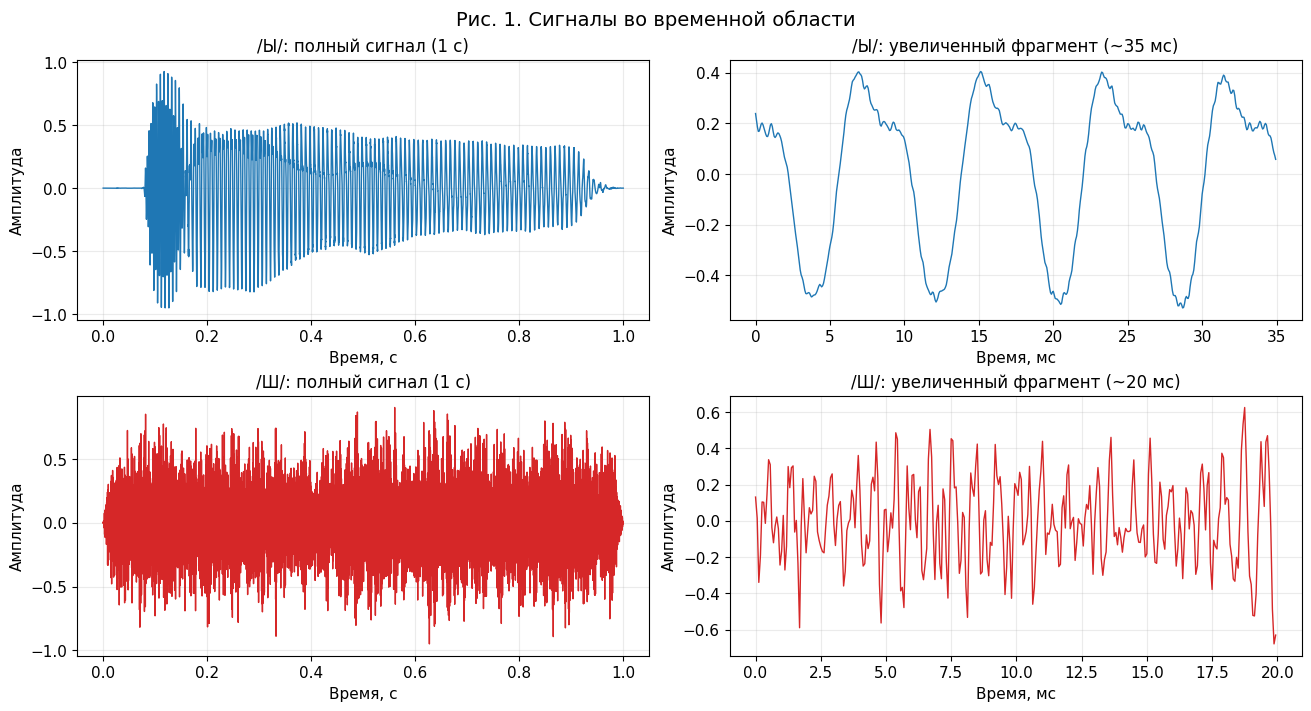

In [18]:
def centered_fragment(x: np.ndarray, fs: int, duration_ms: float) -> tuple[np.ndarray, np.ndarray]:
    n = int(round(duration_ms * 1e-3 * fs))
    n = max(8, min(n, len(x)))
    c = len(x) // 2
    s = max(0, c - n // 2)
    e = min(len(x), s + n)
    frag = x[s:e]
    t = (np.arange(len(frag)) / fs) * 1e3
    return t, frag


t = np.arange(TARGET_SAMPLES) / FS

fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)

axes[0, 0].plot(t, vowel, color='tab:blue', lw=1)
axes[0, 0].set_title('/Ы/: полный сигнал (1 c)')
axes[0, 0].set_xlabel('Время, c')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].grid(alpha=0.25)

zt, zsig = centered_fragment(vowel, FS, duration_ms=35)
axes[0, 1].plot(zt, zsig, color='tab:blue', lw=1)
axes[0, 1].set_title('/Ы/: увеличенный фрагмент (~35 мс)')
axes[0, 1].set_xlabel('Время, мс')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(t, sh, color='tab:red', lw=1)
axes[1, 0].set_title('/Ш/: полный сигнал (1 c)')
axes[1, 0].set_xlabel('Время, c')
axes[1, 0].set_ylabel('Амплитуда')
axes[1, 0].grid(alpha=0.25)

zt2, zsig2 = centered_fragment(sh, FS, duration_ms=20)
axes[1, 1].plot(zt2, zsig2, color='tab:red', lw=1)
axes[1, 1].set_title('/Ш/: увеличенный фрагмент (~20 мс)')
axes[1, 1].set_xlabel('Время, мс')
axes[1, 1].set_ylabel('Амплитуда')
axes[1, 1].grid(alpha=0.25)

fig.suptitle('Рис. 1. Сигналы во временной области', fontsize=14)
plt.show()


---
## Методы

Каждый метод показывает сигнал по-своему: FFT даёт детальный спектр, LPC даёт более гладкую огибающую, кепстр тоже сглаживает спектр другим способом, а Welch уменьшает шум в оценке за счёт усреднения. Вместе это даёт более понятную и надёжную картину.

In [19]:
def pre_emphasis(x: np.ndarray, coeff: float = PRE_EMPH) -> np.ndarray:
    return signal.lfilter([1.0, -coeff], [1.0], x)


def hamming_window(x: np.ndarray) -> np.ndarray:
    return x * np.hamming(len(x))


def select_analysis_frame(
    x: np.ndarray,
    fs: int,
    frame_ms: float = 80.0,
    hop_ms: float = 10.0,
    mode: str = 'vowel',
) -> tuple[np.ndarray, int]:


    frame_len = int(round(frame_ms * 1e-3 * fs))
    hop_len = int(round(hop_ms * 1e-3 * fs))

    if frame_len >= len(x):
        return x.copy(), 0

    starts = np.arange(0, len(x) - frame_len + 1, hop_len, dtype=int)
    rms_vals = []
    zcr_vals = []

    for s in starts:
        fr = x[s:s + frame_len]
        rms_vals.append(np.sqrt(np.mean(fr ** 2) + EPS))
        zcr_vals.append(np.mean(np.abs(np.diff(np.signbit(fr)))))

    rms_vals = np.asarray(rms_vals)
    zcr_vals = np.asarray(zcr_vals)

    rms_norm = (rms_vals - rms_vals.min()) / (np.ptp(rms_vals) + EPS)
    zcr_norm = (zcr_vals - zcr_vals.min()) / (np.ptp(zcr_vals) + EPS)

    if mode == 'vowel':
        score = 0.75 * rms_norm + 0.25 * (1.0 - zcr_norm)
    else:
        score = 0.65 * rms_norm + 0.35 * zcr_norm

    idx = int(np.argmax(score))
    start = int(starts[idx])
    return x[start:start + frame_len].copy(), start


def compute_fft_db(x: np.ndarray, fs: int, nfft: int = NFFT) -> tuple[np.ndarray, np.ndarray]:
    xw = hamming_window(x)
    X = np.fft.rfft(xw, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=1.0 / fs)
    mag_db = 20.0 * np.log10(np.abs(X) + EPS)
    return freqs, mag_db


def burg_lpc(x: np.ndarray, order: int) -> tuple[np.ndarray, float, np.ndarray]:
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    if order < 1 or order >= n:
        raise ValueError('order must satisfy 1 <= order < len(x)')

    ef = x[1:].copy()
    eb = x[:-1].copy()

    a = np.zeros(order + 1, dtype=np.float64)
    a[0] = 1.0
    err = np.dot(x, x) / n
    refl = np.zeros(order, dtype=np.float64)

    for m in range(order):
        den = np.dot(ef, ef) + np.dot(eb, eb) + EPS
        num = -2.0 * np.dot(eb, ef)
        k = num / den
        refl[m] = k

        a_prev = a.copy()
        if m >= 1:
            a[1:m + 1] = a_prev[1:m + 1] + k * a_prev[m:0:-1]
        a[m + 1] = k

        ef_new = ef[1:] + k * eb[1:]
        eb_new = eb[:-1] + k * ef[:-1]
        ef, eb = ef_new, eb_new

        err *= max(1.0 - k * k, EPS)

    return a, float(err), refl


def autocorr_biased(x: np.ndarray, order: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    r = np.empty(order + 1, dtype=np.float64)
    for k in range(order + 1):
        r[k] = np.dot(x[:n - k], x[k:]) / n
    return r


def levinson_durbin(r: np.ndarray, order: int) -> tuple[np.ndarray, float, np.ndarray]:
    r = np.asarray(r, dtype=np.float64)
    if len(r) < order + 1:
        raise ValueError('autocorrelation vector is too short')

    a = np.zeros(order + 1, dtype=np.float64)
    a[0] = 1.0

    err = float(r[0])
    if err <= 0:
        return a, 0.0, np.zeros(order, dtype=np.float64)

    refl = np.zeros(order, dtype=np.float64)

    for i in range(1, order + 1):
        acc = r[i] + np.dot(a[1:i], r[i - 1:0:-1])
        k = -acc / (err + EPS)
        refl[i - 1] = k

        a_prev = a.copy()
        if i > 1:
            a[1:i] = a_prev[1:i] + k * a_prev[i - 1:0:-1]
        a[i] = k

        err *= max(1.0 - k * k, EPS)

    return a, float(err), refl


def lpc_envelope(
    frame: np.ndarray,
    fs: int,
    order: int,
    method: str = 'burg',
    nfft: int = NFFT,
    pre_emph: float = PRE_EMPH,
    align_to_db: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    y = pre_emphasis(frame, pre_emph)
    y = hamming_window(y)

    if method == 'burg':
        a, err, _ = burg_lpc(y, order)
    elif method == 'levinson':
        r = autocorr_biased(y, order)
        a, err, _ = levinson_durbin(r, order)
    else:
        raise ValueError("method must be 'burg' or 'levinson'")

    freqs, h = signal.freqz([1.0], a, worN=nfft // 2 + 1, fs=fs)
    env_db = 20.0 * np.log10(np.abs(h) + EPS)

    if align_to_db is not None:
        env_db = env_db + (np.max(align_to_db) - np.max(env_db))

    return freqs, env_db, a, err


def cepstral_envelope(
    frame: np.ndarray,
    fs: int,
    nfft: int = NFFT,
    lifter_bins: int = LIFTER_BINS,
    align_to_db: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    xw = hamming_window(frame)
    X = np.fft.fft(xw, n=nfft)
    log_mag = np.log(np.abs(X) + EPS)

    cep = np.fft.ifft(log_mag).real
    liftered = np.zeros_like(cep)

    lifter_bins = int(max(1, min(lifter_bins, nfft // 2 - 1)))
    liftered[:lifter_bins + 1] = cep[:lifter_bins + 1]
    liftered[-lifter_bins:] = cep[-lifter_bins:]

    env_log = np.fft.fft(liftered).real
    env_db_full = (20.0 / np.log(10.0)) * env_log

    freqs = np.fft.rfftfreq(nfft, d=1.0 / fs)
    env_db = env_db_full[:nfft // 2 + 1]

    if align_to_db is not None:
        env_db = env_db + (np.max(align_to_db) - np.max(env_db))

    return freqs, env_db


def welch_psd_db(
    frame: np.ndarray,
    fs: int,
    nfft: int = NFFT,
    nperseg: int = WELCH_NPERSEG,
    noverlap: int = WELCH_NOVERLAP,
    align_to_db: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    nperseg_eff = min(nperseg, len(frame))
    noverlap_eff = min(noverlap, max(0, nperseg_eff - 1))

    freqs, psd = signal.welch(
        frame,
        fs=fs,
        window='hamming',
        nperseg=nperseg_eff,
        noverlap=noverlap_eff,
        nfft=nfft,
        detrend=False,
        scaling='density',
    )
    psd_db = 10.0 * np.log10(psd + EPS)

    if align_to_db is not None:
        psd_db = psd_db + (np.max(align_to_db) - np.max(psd_db))

    return freqs, psd_db


def find_spectral_peaks(
    freqs: np.ndarray,
    db: np.ndarray,
    fmin: float = 80.0,
    fmax: float = 7600.0,
    n_peaks: int = 6,
    min_distance_hz: float = 220.0,
    prominence_db: float = 0.8,
) -> tuple[np.ndarray, np.ndarray]:
    mask = (freqs >= fmin) & (freqs <= fmax)
    f = freqs[mask]
    y = db[mask]

    if len(f) < 3:
        return np.array([]), np.array([])

    df = f[1] - f[0]
    distance_bins = max(1, int(round(min_distance_hz / max(df, EPS))))

    peaks, _ = signal.find_peaks(y, distance=distance_bins, prominence=prominence_db)
    if len(peaks) == 0:
        return np.array([]), np.array([])

    amp_order = np.argsort(y[peaks])[::-1]
    take = amp_order[:n_peaks]
    selected = np.sort(peaks[take])

    return f[selected], y[selected]


def formants_from_lpc_roots(
    a: np.ndarray,
    fs: int,
    fmin: float = 80.0,
    fmax: float = 7600.0,
    bw_min: float = 20.0,
    bw_max: float = 1000.0,
) -> tuple[np.ndarray, np.ndarray]:
    roots = np.roots(a)
    roots = roots[np.imag(roots) > 0.01]

    freqs = np.angle(roots) * fs / (2.0 * np.pi)
    bw = -(fs / np.pi) * np.log(np.abs(roots) + EPS)

    valid = (
        (freqs >= fmin) & (freqs <= fmax) &
        (bw >= bw_min) & (bw <= bw_max)
    )
    freqs = freqs[valid]
    bw = bw[valid]

    idx = np.argsort(freqs)
    return freqs[idx], bw[idx]


def lpc_residual(x: np.ndarray, a: np.ndarray, pre_emph: float = PRE_EMPH) -> np.ndarray:
    x_pre = pre_emphasis(x, pre_emph)
    r = signal.lfilter(a, [1.0], x_pre)
    return r


def estimate_f0_from_fft(freqs: np.ndarray, db: np.ndarray, fmin: float = 70.0, fmax: float = 300.0) -> float:
    mask = (freqs >= fmin) & (freqs <= fmax)
    f = freqs[mask]
    y = db[mask]
    if len(f) == 0:
        return float('nan')
    return float(f[np.argmax(y)])


def spectral_flatness(frame: np.ndarray, nfft: int = NFFT) -> float:
    xw = hamming_window(frame)
    X = np.abs(np.fft.rfft(xw, n=nfft)) + EPS
    gm = np.exp(np.mean(np.log(X)))
    am = np.mean(X)
    return float(gm / am)


In [20]:
vowel_frame, vowel_frame_start = select_analysis_frame(vowel, FS, frame_ms=80, hop_ms=10, mode='vowel')
sh_frame, sh_frame_start = select_analysis_frame(sh, FS, frame_ms=80, hop_ms=10, mode='sh')

print(f'/Ы/ анализируемый кадр: старт {vowel_frame_start/FS:.3f} c, длина {len(vowel_frame)/FS*1000:.1f} мс')
print(f'/Ш/ анализируемый кадр: старт {sh_frame_start/FS:.3f} c, длина {len(sh_frame)/FS*1000:.1f} мс')


fv_fft, vowel_fft_db = compute_fft_db(vowel_frame, FS, nfft=NFFT)
fs_fft, sh_fft_db = compute_fft_db(sh_frame, FS, nfft=NFFT)

fv_burg, vowel_burg_db, a_vowel_burg, err_vowel_burg = lpc_envelope(
    vowel_frame, FS, P_OPT, method='burg', nfft=NFFT, align_to_db=vowel_fft_db
)
fs_burg, sh_burg_db, a_sh_burg, err_sh_burg = lpc_envelope(
    sh_frame, FS, P_OPT, method='burg', nfft=NFFT, align_to_db=sh_fft_db
)

fv_lev, vowel_lev_db, a_vowel_lev, err_vowel_lev = lpc_envelope(
    vowel_frame, FS, P_OPT, method='levinson', nfft=NFFT, align_to_db=vowel_fft_db
)
fs_lev, sh_lev_db, a_sh_lev, err_sh_lev = lpc_envelope(
    sh_frame, FS, P_OPT, method='levinson', nfft=NFFT, align_to_db=sh_fft_db
)

fv_cep, vowel_cep_db = cepstral_envelope(vowel_frame, FS, nfft=NFFT, lifter_bins=LIFTER_BINS, align_to_db=vowel_fft_db)
fs_cep, sh_cep_db = cepstral_envelope(sh_frame, FS, nfft=NFFT, lifter_bins=LIFTER_BINS, align_to_db=sh_fft_db)

fv_welch, vowel_welch_db = welch_psd_db(vowel_frame, FS, nfft=NFFT, nperseg=WELCH_NPERSEG, noverlap=WELCH_NOVERLAP, align_to_db=vowel_fft_db)
fs_welch, sh_welch_db = welch_psd_db(sh_frame, FS, nfft=NFFT, nperseg=WELCH_NPERSEG, noverlap=WELCH_NOVERLAP, align_to_db=sh_fft_db)


vowel_ref_formants, _ = find_spectral_peaks(
    fv_cep,
    signal.savgol_filter(vowel_cep_db, 31, 3),
    fmin=120,
    fmax=7600,
    n_peaks=5,
    min_distance_hz=450,
    prominence_db=0.7,
)

print('Референсные частоты /Ы/ из кепстральной огибающей, Гц:')
print(np.round(vowel_ref_formants, 1))


/Ы/ анализируемый кадр: старт 0.090 c, длина 80.0 мс
/Ш/ анализируемый кадр: старт 0.590 c, длина 80.0 мс
Референсные частоты /Ы/ из кепстральной огибающей, Гц:
[ 281.2 1820.3 2343.8 2828.1 3898.4]


---
## FFT-спектры

Здесь смотрим обычные FFT-спектры для `Ы` и `Ш`.

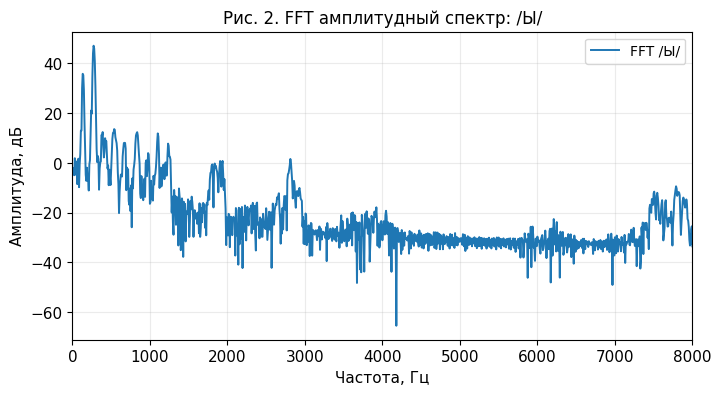

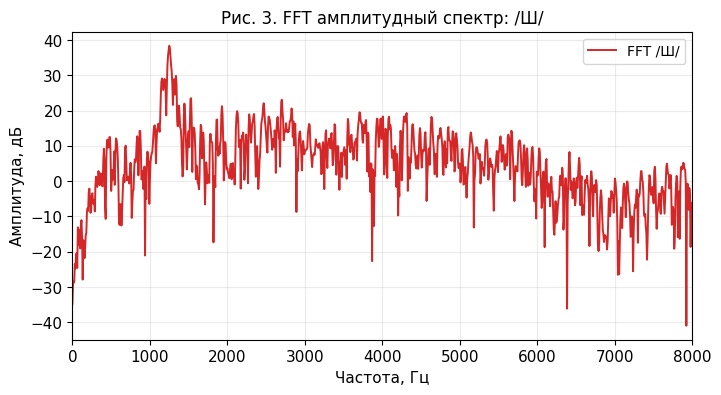

In [21]:
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(fv_fft, vowel_fft_db, color='tab:blue', lw=1.4, label='FFT /Ы/')
ax1.set_title('Рис. 2. FFT амплитудный спектр: /Ы/')
ax1.set_xlabel('Частота, Гц')
ax1.set_ylabel('Амплитуда, дБ')
ax1.set_xlim(0, 8000)
ax1.grid(alpha=0.25)
ax1.legend(loc='best')
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(fs_fft, sh_fft_db, color='tab:red', lw=1.4, label='FFT /Ш/')
ax2.set_title('Рис. 3. FFT амплитудный спектр: /Ш/')
ax2.set_xlabel('Частота, Гц')
ax2.set_ylabel('Амплитуда, дБ')
ax2.set_xlim(0, 8000)
ax2.grid(alpha=0.25)
ax2.legend(loc='best')
plt.show()


---
## Как влияет порядок LPC

Проверяем порядки `p = 4, 8, 12, 18, 26, 40`.

Малый `p` слишком сглаживает, `p≈18` обычно даёт хороший баланс, большой `p` может подхватывать лишние мелкие пики.

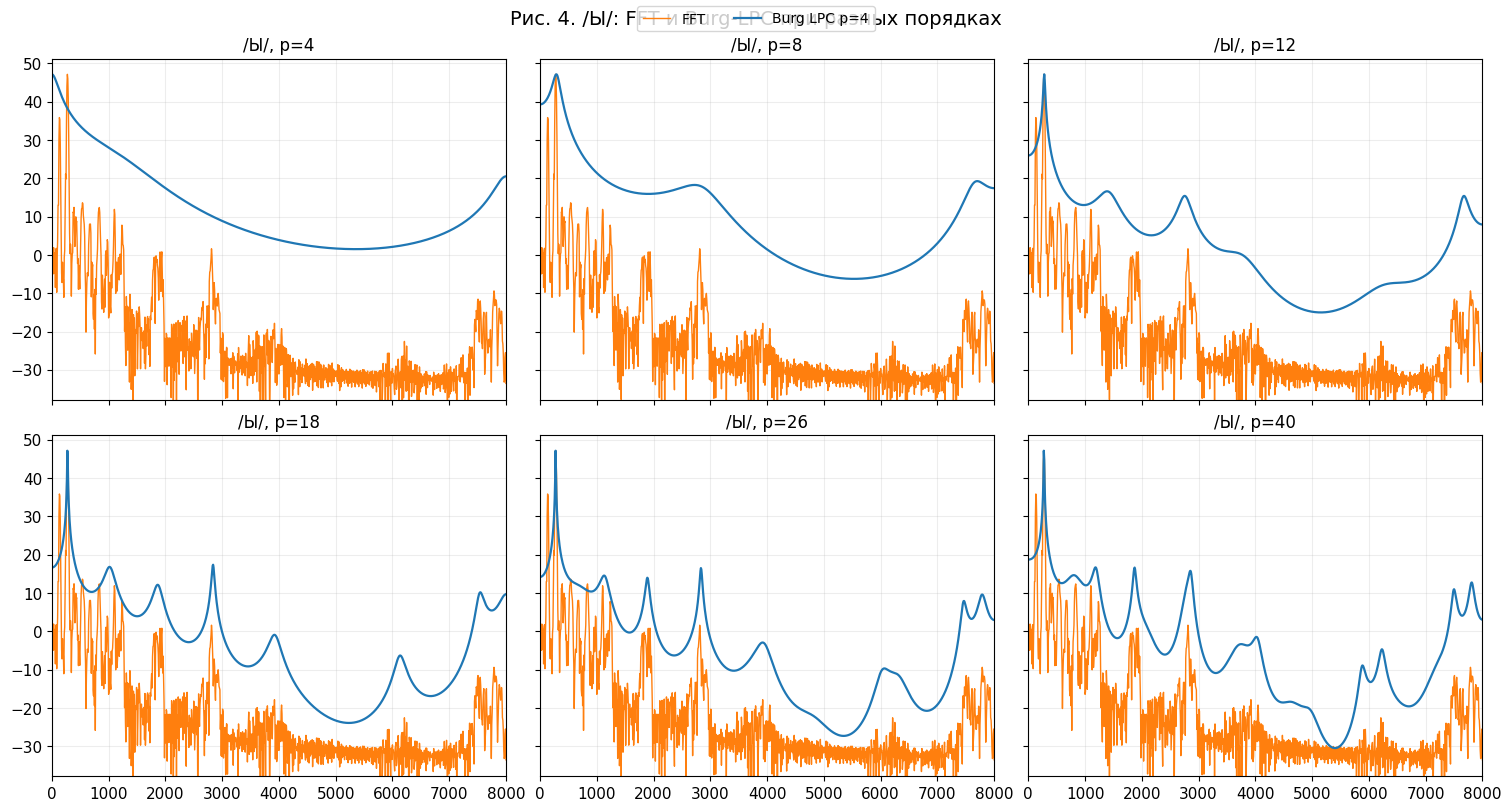

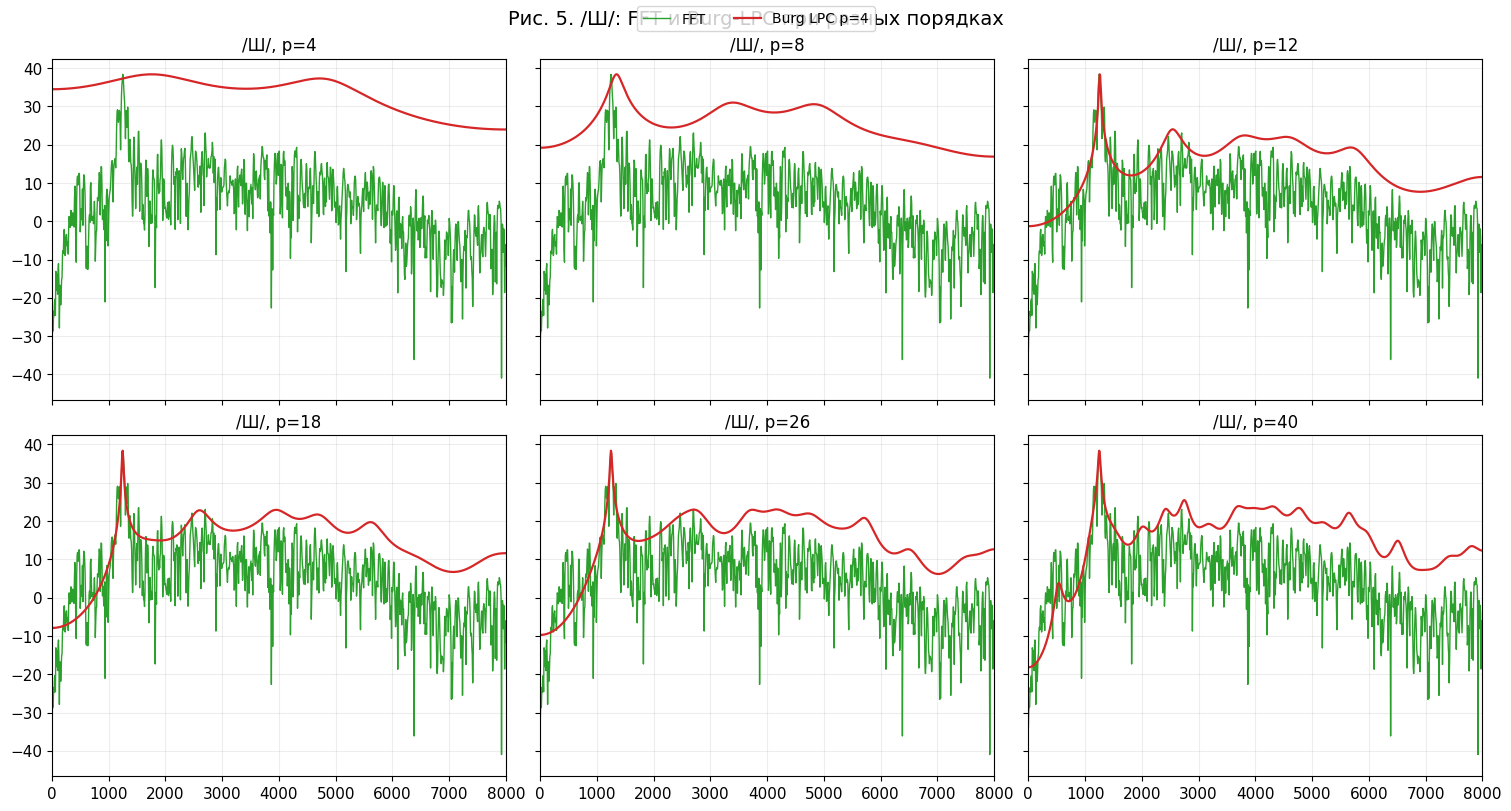

In [22]:
orders_burg_vowel = {}
orders_burg_sh = {}

for p in LPC_ORDERS:
    fvb, dbv, av, _ = lpc_envelope(vowel_frame, FS, p, method='burg', nfft=NFFT, align_to_db=vowel_fft_db)
    fsb, dbs, ash, _ = lpc_envelope(sh_frame, FS, p, method='burg', nfft=NFFT, align_to_db=sh_fft_db)
    orders_burg_vowel[p] = (fvb, dbv, av)
    orders_burg_sh[p] = (fsb, dbs, ash)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)
for ax, p in zip(axes.ravel(), LPC_ORDERS):
    f, env, _ = orders_burg_vowel[p]
    ax.plot(fv_fft, vowel_fft_db, color='tab:orange', lw=1.0, label='FFT')
    ax.plot(f, env, color='tab:blue', lw=1.6, label=f'Burg LPC p={p}')
    ax.set_title(f'/Ы/, p={p}')
    ax.set_xlim(0, 8000)
    ax.set_ylim(np.max(vowel_fft_db)-85, np.max(vowel_fft_db)+4)
    ax.grid(alpha=0.22)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Рис. 4. /Ы/: FFT и Burg-LPC при разных порядках', fontsize=14)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)
for ax, p in zip(axes.ravel(), LPC_ORDERS):
    f, env, _ = orders_burg_sh[p]
    ax.plot(fs_fft, sh_fft_db, color='tab:green', lw=1.0, label='FFT')
    ax.plot(f, env, color='tab:red', lw=1.6, label=f'Burg LPC p={p}')
    ax.set_title(f'/Ш/, p={p}')
    ax.set_xlim(0, 8000)
    ax.set_ylim(np.max(sh_fft_db)-85, np.max(sh_fft_db)+4)
    ax.grid(alpha=0.22)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Рис. 5. /Ш/: FFT и Burg-LPC при разных порядках', fontsize=14)
plt.show()


---
## Сравнение методов

На одном графике накладываем FFT, Burg, Левинсон, кепстр и Welch.

Кривую Welch по уровню подгоняем только для удобного сравнения на рисунке.

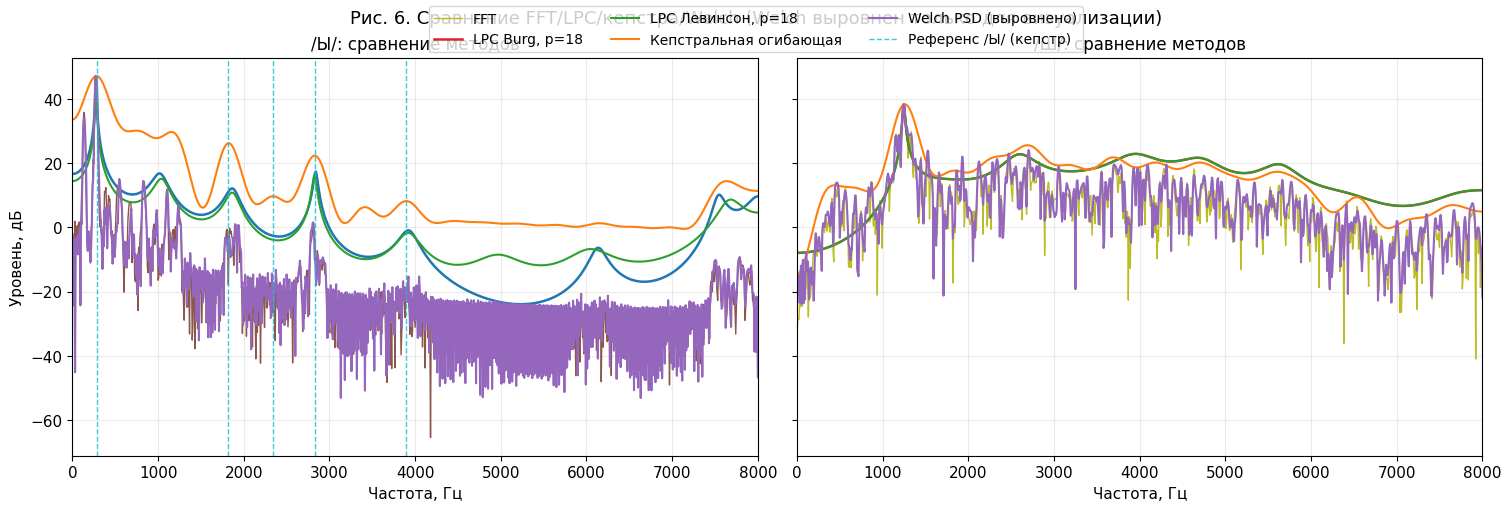

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

ax = axes[0]
ax.plot(fv_fft, vowel_fft_db, color='tab:brown', lw=1.0, label='FFT')
ax.plot(fv_burg, vowel_burg_db, color='tab:blue', lw=1.8, label='LPC Burg, p=18')
ax.plot(fv_lev, vowel_lev_db, color='tab:green', lw=1.5, label='LPC Левинсон, p=18')
ax.plot(fv_cep, vowel_cep_db, color='tab:orange', lw=1.5, label='Кепстральная огибающая')
ax.plot(fv_welch, vowel_welch_db, color='tab:purple', lw=1.5, label='Welch PSD (выровнено)')
for i, ff in enumerate(vowel_ref_formants):
    ax.axvline(ff, color='tab:cyan', ls='--', lw=1.0, alpha=0.85,
               label='Референс /Ы/ (кепстр)' if i == 0 else None)
ax.set_title('/Ы/: сравнение методов')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(fs_fft, sh_fft_db, color='tab:olive', lw=1.0, label='FFT')
ax.plot(fs_burg, sh_burg_db, color='tab:red', lw=1.8, label='LPC Burg, p=18')
ax.plot(fs_lev, sh_lev_db, color='tab:green', lw=1.5, label='LPC Левинсон, p=18')
ax.plot(fs_cep, sh_cep_db, color='tab:orange', lw=1.5, label='Кепстральная огибающая')
ax.plot(fs_welch, sh_welch_db, color='tab:purple', lw=1.5, label='Welch PSD (выровнено)')
ax.set_title('/Ш/: сравнение методов')
ax.set_xlabel('Частота, Гц')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
all_items = list(dict(zip(labels + labels2, handles + handles2)).items())
fig.legend([h for _, h in all_items], [l for l, _ in all_items], loc='upper center', ncol=3)
fig.suptitle('Рис. 6. Сравнение FFT/LPC/кепстра/Welch (Welch выровнен только для визуализации)', fontsize=13)
plt.show()


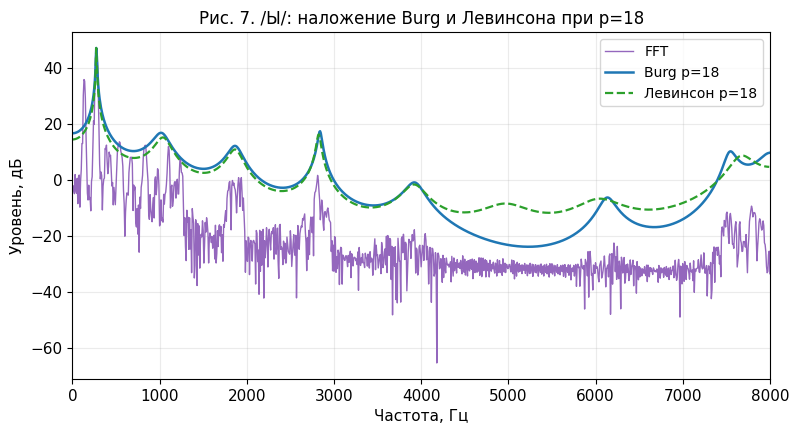

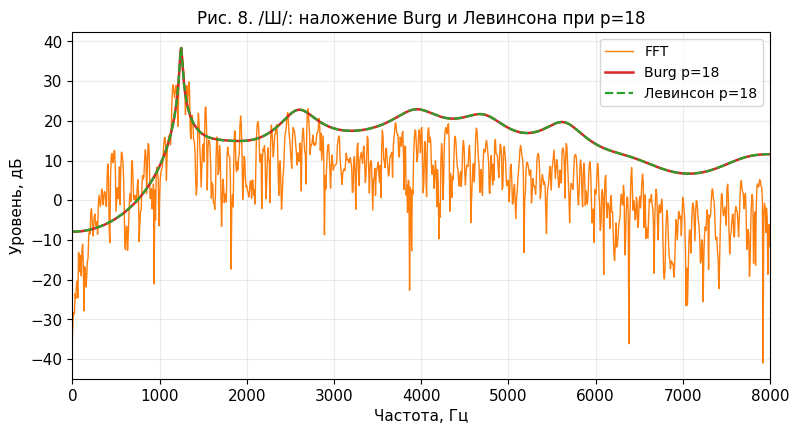

Корреляция Burg vs Levinson (/Ы/): 0.95547
Корреляция Burg vs Levinson (/Ш/): 1.00000


In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fv_fft, vowel_fft_db, color='tab:purple', lw=1.0, label='FFT')
ax.plot(fv_burg, vowel_burg_db, color='tab:blue', lw=1.8, label='Burg p=18')
ax.plot(fv_lev, vowel_lev_db, color='tab:green', lw=1.6, ls='--', label='Левинсон p=18')
ax.set_title('Рис. 7. /Ы/: наложение Burg и Левинсона при p=18')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fs_fft, sh_fft_db, color='tab:orange', lw=1.0, label='FFT')
ax.plot(fs_burg, sh_burg_db, color='tab:red', lw=1.8, label='Burg p=18')
ax.plot(fs_lev, sh_lev_db, color='tab:green', lw=1.6, ls='--', label='Левинсон p=18')
ax.set_title('Рис. 8. /Ш/: наложение Burg и Левинсона при p=18')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

corr_vowel = float(np.corrcoef(vowel_burg_db, vowel_lev_db)[0, 1])
corr_sh = float(np.corrcoef(sh_burg_db, sh_lev_db)[0, 1])

print(f'Корреляция Burg vs Levinson (/Ы/): {corr_vowel:.5f}')
print(f'Корреляция Burg vs Levinson (/Ш/): {corr_sh:.5f}')


---
## Корни LPC-полинома

Для `p=18` берём корни `A(z)`, переводим их в частоты и полосы, и оставляем только разумные значения.

Для `Ы` это похоже на формантные области, для `Ш` — на основные шумовые пики.

Таблица для /Ы/ (корни LPC, p=18):
 № | Найденная, Гц | Полоса, Гц | Ближайшая реф., Гц | Ошибка, Гц
-----------------------------------------------------------------
 1 |        1023.4 |      178.6 |              281.2 |      742.1
 2 |        1869.6 |      160.4 |             1820.3 |       49.2
 3 |        2839.5 |       45.4 |             2828.1 |       11.3
 4 |        3928.6 |      204.0 |             3898.4 |       30.1
 5 |        6132.6 |      178.4 |             3898.4 |     2234.1
 6 |        7537.3 |      128.4 |             3898.4 |     3638.8
Референс 281.2 Гц: нет уверенного совпадения (мин. ошибка 742.1 Гц)
Референс 2343.8 Гц: нет уверенного совпадения (мин. ошибка 474.2 Гц)


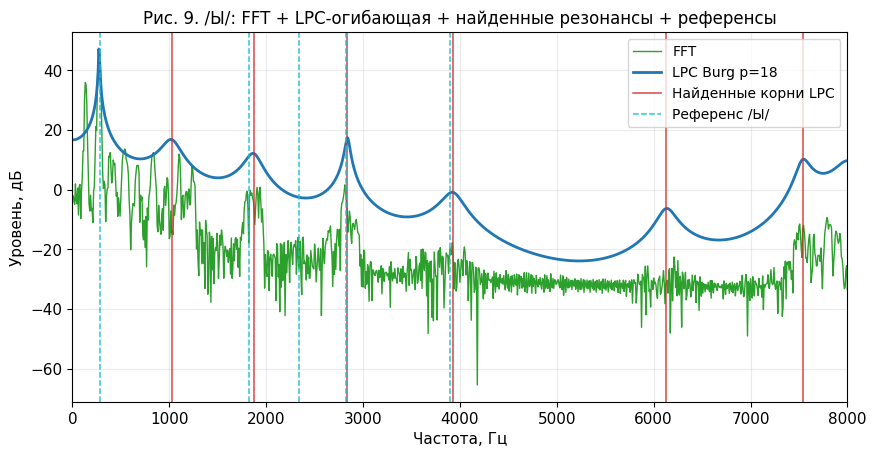

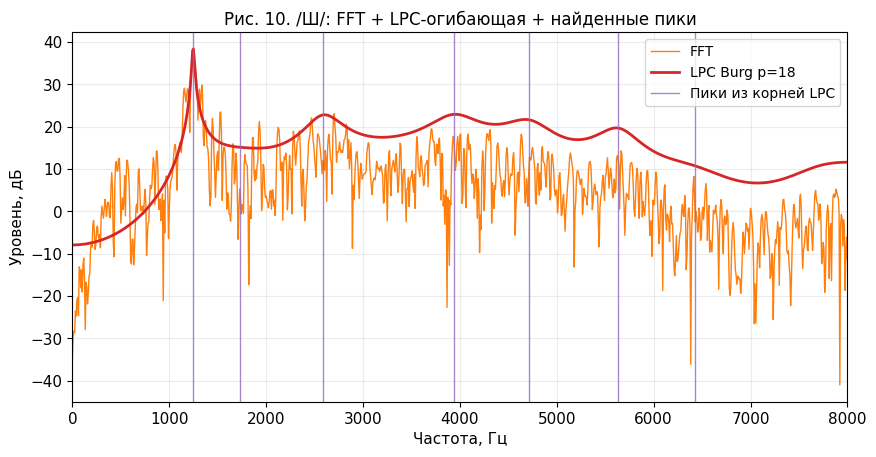

Найденные пики /Ш/ (Гц): [1245.5, 1731.1, 2591.2, 3941.6, 4715.2, 5635.3, 6426.2]


In [25]:
vowel_formant_freqs, vowel_formant_bw = formants_from_lpc_roots(
    a_vowel_burg, FS, fmin=80, fmax=7600, bw_min=20, bw_max=1000
)

sh_peak_freqs, sh_peak_bw = formants_from_lpc_roots(
    a_sh_burg, FS, fmin=600, fmax=7600, bw_min=20, bw_max=1200
)

n_show = min(6, len(vowel_formant_freqs))

if len(vowel_ref_formants) == 0:
    vowel_ref_formants = np.array([300.0, 900.0, 1700.0, 2800.0, 4500.0])

rows = []
for i in range(n_show):
    ff = float(vowel_formant_freqs[i])
    bw = float(vowel_formant_bw[i])
    j = int(np.argmin(np.abs(vowel_ref_formants - ff)))
    ref = float(vowel_ref_formants[j])
    err = abs(ff - ref)
    rows.append((i + 1, ff, bw, ref, err))

header = f"{'№':>2} | {'Найденная, Гц':>13} | {'Полоса, Гц':>10} | {'Ближайшая реф., Гц':>18} | {'Ошибка, Гц':>10}"
sep = '-' * len(header)
print('Таблица для /Ы/ (корни LPC, p=18):')
print(header)
print(sep)
for r in rows:
    print(f"{r[0]:2d} | {r[1]:13.1f} | {r[2]:10.1f} | {r[3]:18.1f} | {r[4]:10.1f}")

for ref in vowel_ref_formants:
    if len(vowel_formant_freqs) == 0:
        print(f'Референс {ref:.1f} Гц: не найдено')
    else:
        d = np.min(np.abs(vowel_formant_freqs - ref))
        if d > 300:
            print(f'Референс {ref:.1f} Гц: нет уверенного совпадения (мин. ошибка {d:.1f} Гц)')

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(fv_fft, vowel_fft_db, color='tab:green', lw=1.0, label='FFT')
ax.plot(fv_burg, vowel_burg_db, color='tab:blue', lw=2.0, label='LPC Burg p=18')

for i, ff in enumerate(vowel_formant_freqs[:n_show]):
    ax.axvline(ff, color='tab:red', ls='-', lw=1.1, alpha=0.85,
               label='Найденные корни LPC' if i == 0 else None)

for i, ref in enumerate(vowel_ref_formants):
    ax.axvline(ref, color='tab:cyan', ls='--', lw=1.1, alpha=0.9,
               label='Референс /Ы/' if i == 0 else None)

ax.set_title('Рис. 9. /Ы/: FFT + LPC-огибающая + найденные резонансы + референсы')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(fs_fft, sh_fft_db, color='tab:orange', lw=1.0, label='FFT')
ax.plot(fs_burg, sh_burg_db, color='tab:red', lw=2.0, label='LPC Burg p=18')

for i, ff in enumerate(sh_peak_freqs):
    ax.axvline(ff, color='tab:purple', ls='-', lw=1.0, alpha=0.8,
               label='Пики из корней LPC' if i == 0 else None)

ax.set_title('Рис. 10. /Ш/: FFT + LPC-огибающая + найденные пики')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

print('Найденные пики /Ш/ (Гц):', np.round(sh_peak_freqs, 1).tolist())


---
## Спектрограммы и LPC residual

Строим спектрограммы (`n_fft=1024`, `hop=256`) и сравниваем короткие куски исходного сигнала и residual (около `40 мс`).

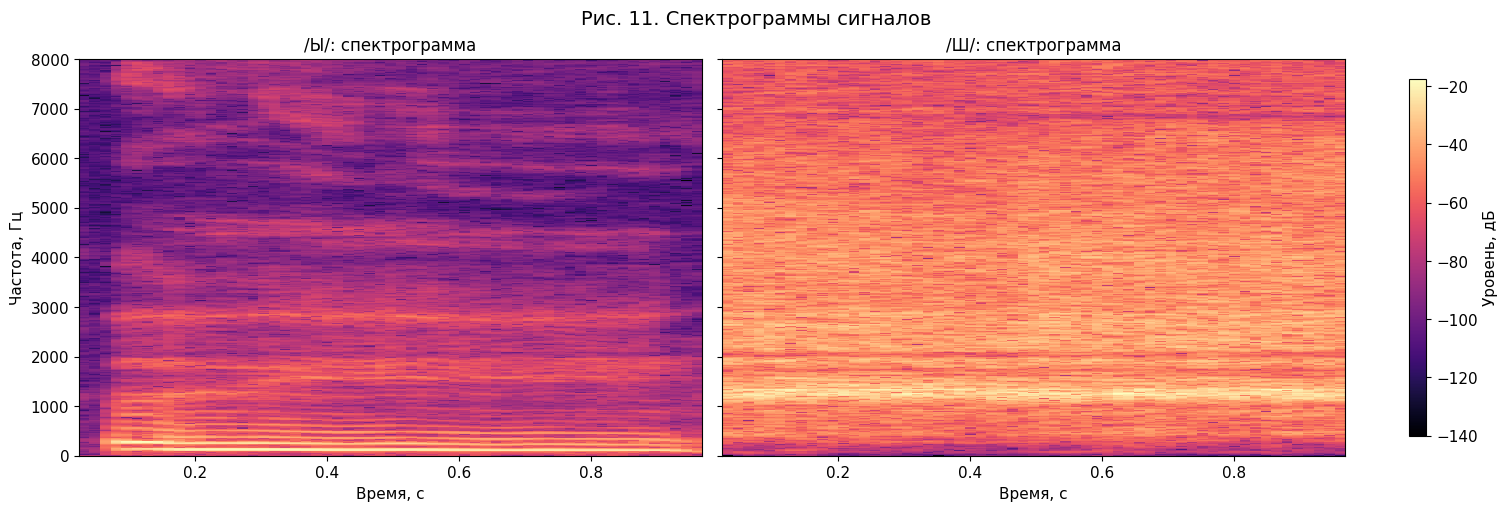

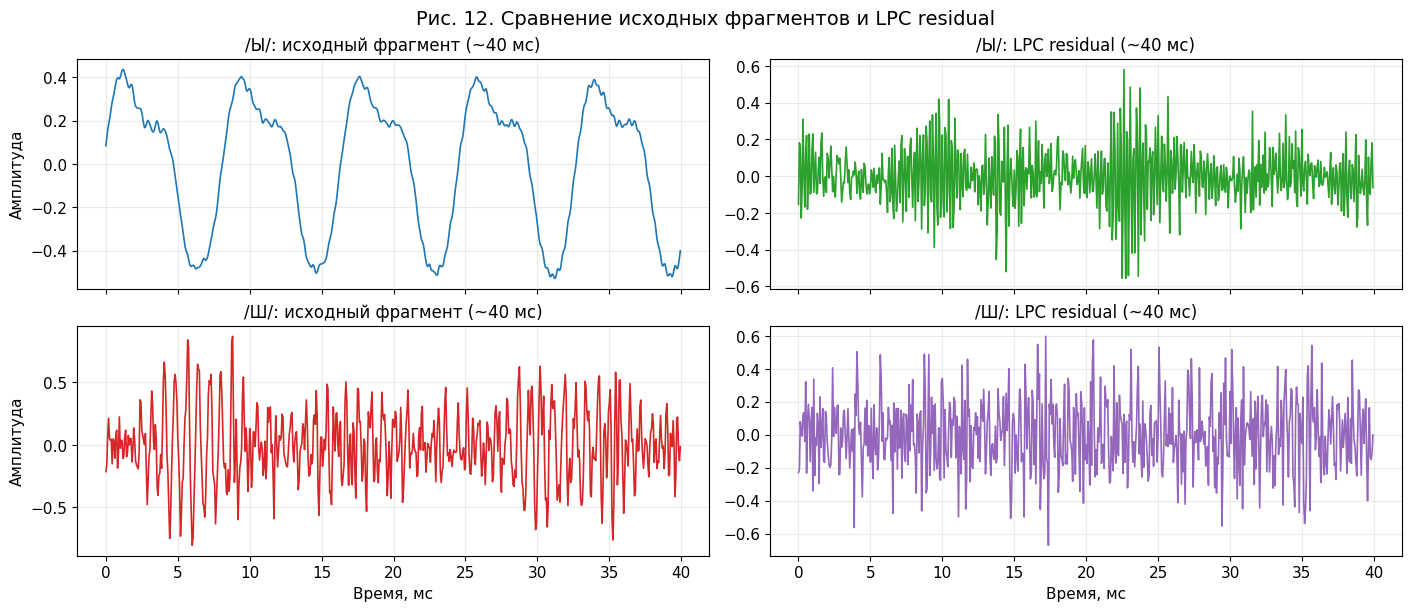

In [26]:
def stft_db(x: np.ndarray, fs: int, n_fft: int = 1024, hop_length: int = 256):
    f, t, Z = signal.stft(
        x,
        fs=fs,
        window='hann',
        nperseg=n_fft,
        noverlap=n_fft - hop_length,
        nfft=n_fft,
        boundary=None,
        padded=False,
    )
    S_db = 20.0 * np.log10(np.abs(Z) + EPS)
    return f, t, S_db


f_v, t_v, S_v = stft_db(vowel, FS, n_fft=1024, hop_length=256)
f_s, t_s, S_s = stft_db(sh, FS, n_fft=1024, hop_length=256)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

im0 = axes[0].pcolormesh(t_v, f_v, S_v, shading='auto', cmap='magma')
axes[0].set_title('/Ы/: спектрограмма')
axes[0].set_xlabel('Время, c')
axes[0].set_ylabel('Частота, Гц')
axes[0].set_ylim(0, 8000)

im1 = axes[1].pcolormesh(t_s, f_s, S_s, shading='auto', cmap='magma')
axes[1].set_title('/Ш/: спектрограмма')
axes[1].set_xlabel('Время, c')
axes[1].set_ylim(0, 8000)

cbar = fig.colorbar(im1, ax=axes, location='right', shrink=0.9)
cbar.set_label('Уровень, дБ')
fig.suptitle('Рис. 11. Спектрограммы сигналов', fontsize=14)
plt.show()

res_vowel = lpc_residual(vowel, a_vowel_burg, pre_emph=PRE_EMPH)
res_sh = lpc_residual(sh, a_sh_burg, pre_emph=PRE_EMPH)

res_vowel = normalize_peak(res_vowel, target_peak=0.95)
res_sh = normalize_peak(res_sh, target_peak=0.95)

frag_ms = 40.0
frag_n = int(round(frag_ms * 1e-3 * FS))

t_frag = np.arange(frag_n) / FS * 1e3

center = len(vowel) // 2
sv = max(0, center - frag_n // 2)
ev = sv + frag_n

center = len(sh) // 2
ss = max(0, center - frag_n // 2)
es = ss + frag_n

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True, constrained_layout=True)

axes[0, 0].plot(t_frag, vowel[sv:ev], color='tab:blue', lw=1.2)
axes[0, 0].set_title('/Ы/: исходный фрагмент (~40 мс)')
axes[0, 0].set_ylabel('Амплитуда')
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(t_frag, res_vowel[sv:ev], color='tab:green', lw=1.2)
axes[0, 1].set_title('/Ы/: LPC residual (~40 мс)')
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(t_frag, sh[ss:es], color='tab:red', lw=1.2)
axes[1, 0].set_title('/Ш/: исходный фрагмент (~40 мс)')
axes[1, 0].set_xlabel('Время, мс')
axes[1, 0].set_ylabel('Амплитуда')
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(t_frag, res_sh[ss:es], color='tab:purple', lw=1.2)
axes[1, 1].set_title('/Ш/: LPC residual (~40 мс)')
axes[1, 1].set_xlabel('Время, мс')
axes[1, 1].grid(alpha=0.25)

fig.suptitle('Рис. 12. Сравнение исходных фрагментов и LPC residual', fontsize=14)
plt.show()


---
## Сводка по порядкам LPC

Сравниваем `p = 8, 18, 40` для обоих сигналов на одном рисунке.

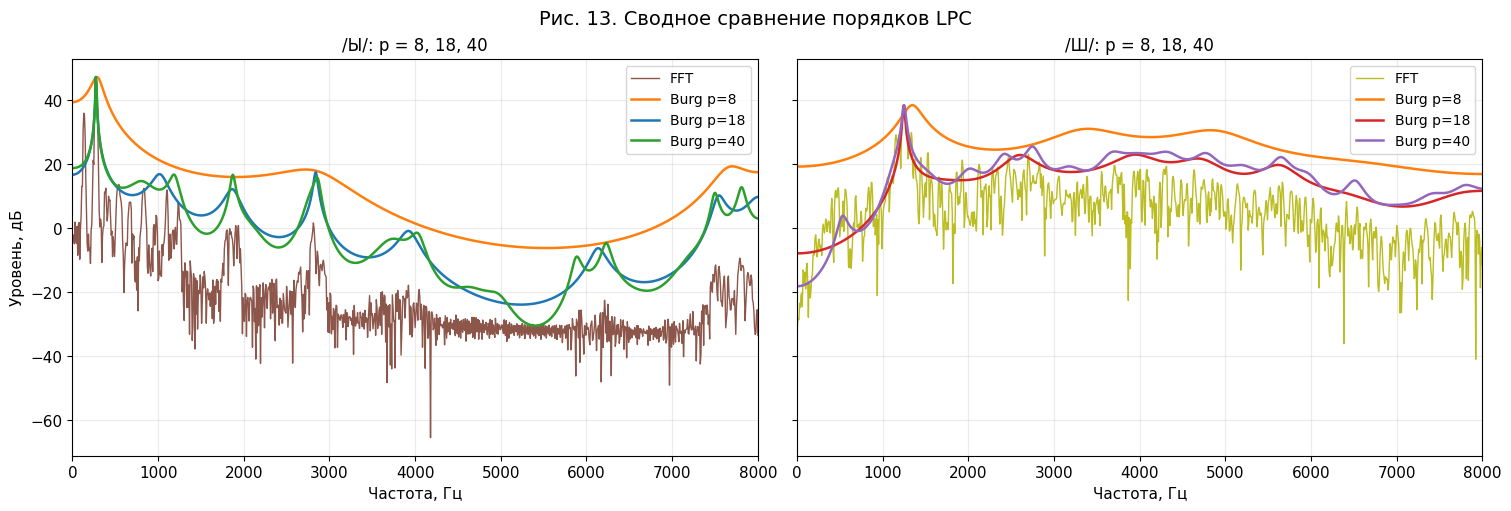

In [27]:
summary_orders = [8, 18, 40]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)

ax = axes[0]
ax.plot(fv_fft, vowel_fft_db, color='tab:brown', lw=1.0, label='FFT')
for p, color in zip(summary_orders, ['tab:orange', 'tab:blue', 'tab:green']):
    f, db, _ = orders_burg_vowel[p]
    ax.plot(f, db, lw=1.8, color=color, label=f'Burg p={p}')
ax.set_title('/Ы/: p = 8, 18, 40')
ax.set_xlabel('Частота, Гц')
ax.set_ylabel('Уровень, дБ')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')

ax = axes[1]
ax.plot(fs_fft, sh_fft_db, color='tab:olive', lw=1.0, label='FFT')
for p, color in zip(summary_orders, ['tab:orange', 'tab:red', 'tab:purple']):
    f, db, _ = orders_burg_sh[p]
    ax.plot(f, db, lw=1.8, color=color, label=f'Burg p={p}')
ax.set_title('/Ш/: p = 8, 18, 40')
ax.set_xlabel('Частота, Гц')
ax.set_xlim(0, 8000)
ax.grid(alpha=0.25)
ax.legend(loc='best')

fig.suptitle('Рис. 13. Сводное сравнение порядков LPC', fontsize=14)
plt.show()


### Итог

`Ы` и `Ш` хорошо разделяются по спектральной картине: у `Ы` структура более регулярная, у `Ш` — более шумовая и широкополосная. LPC-огибающие помогают увидеть форму спектра без мелких колебаний, а Burg и Левинсон дают близкие, но не полностью одинаковые кривые. Кепстральная огибающая и Welch дополняют картину и делают сравнение устойчивее. По порядку LPC видно, что слишком маленький `p` сглаживает лишнее, слишком большой `p` начинает ловить мелкие пики, а `p=18` даёт наиболее разумный баланс для этой задачи.